In [1]:
from __future__ import annotations

import io
import platform
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import modal
import numpy as np
import pandas as pd
import seaborn as sns
import sklearn
import statsmodels.api as sm
import statsmodels.formula.api as smf
from IPython.display import Markdown, display
from patsy import bs
from scipy.optimize import brentq
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import brier_score_loss, roc_auc_score
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", message="cov_type not fully supported with freq_weights")
sns.set_theme(style="whitegrid", context="notebook")
SEED = 20260711
rng = np.random.default_rng(SEED)

versions = pd.Series({
    "python": platform.python_version(), "numpy": np.__version__, "pandas": pd.__version__,
    "sklearn": sklearn.__version__, "statsmodels": sm.__version__, "modal": modal.__version__,
})
versions.to_frame("version")

,version
python,3.12.13
numpy,2.3.5
pandas,2.2.3
sklearn,1.8.0
statsmodels,0.14.6
modal,1.4.3


In [2]:
ROOT = Path.cwd()
if not (ROOT / "data_steps").exists():
    raise FileNotFoundError("저장소 루트에서 노트북을 실행해야 합니다.")

local_remote_files = {
    ROOT / "data_steps/csv/nhanes_1440_scsslsteps.csv.xz": "/data/steps.csv.xz",
    ROOT / "data_steps/csv/nhanes_1440_PAXPREDM.csv.xz": "/data/state.csv.xz",
    ROOT / "data_steps/csv/nhanes_1440_PAXFLGSM.csv.xz": "/data/flag.csv.xz",
    ROOT / "data_monitor/PAXDAY_G.xpt": "/data/PAXDAY_G.xpt",
    ROOT / "data_monitor/PAXDAY_H.xpt": "/data/PAXDAY_H.xpt",
}
for cycle in "GH":
    for stem in ["DEMO", "BMX", "BPX", "GHB", "BIOPRO", "HDL", "TCHOL", "MCQ", "DIQ", "BPQ", "SMQ"]:
        local_remote_files[ROOT / f"data_NHANES/{stem}_{cycle}.xpt"] = f"/data/{stem}_{cycle}.xpt"

missing = [str(path) for path in local_remote_files if not path.exists()]
if missing:
    raise FileNotFoundError(f"필요한 원자료가 없습니다: {missing[:3]}")

remote_image = modal.Image.debian_slim(python_version="3.12").uv_pip_install(
    "numpy==2.3.5", "pandas==2.2.3", "pyarrow==23.0.0"
)
for local_path, remote_path in local_remote_files.items():
    remote_image = remote_image.add_local_file(local_path, remote_path)

app = modal.App("wearable-insurance-sweet-spot")


@app.function(image=remote_image, cpu=8, memory=16384, timeout=1200)
def aggregate_cohort() -> bytes:
    import io
    import numpy as np
    import pandas as pd

    ids = ["SEQN", "PAXDAYM", "PAXDAYWM"]
    readers = [
        pd.read_csv("/data/steps.csv.xz", chunksize=2048, na_values="NA"),
        pd.read_csv("/data/state.csv.xz", chunksize=2048, na_values="NA"),
        pd.read_csv("/data/flag.csv.xz", chunksize=2048, na_values="NA", true_values=["TRUE"], false_values=["FALSE"]),
    ]
    summaries = []
    for step, state, flag in zip(*readers, strict=True):
        keys = step[ids].reset_index(drop=True)
        if not (keys.equals(state[ids].reset_index(drop=True)) and keys.equals(flag[ids].reset_index(drop=True))):
            raise ValueError("분 단위 파일의 행 키가 일치하지 않습니다.")
        cols = [c for c in step if c.startswith("min_")]
        x = step[cols].to_numpy(dtype="float32", na_value=np.nan)
        state_x = state[cols].to_numpy(dtype="float32", na_value=np.nan)
        flag_true = flag[cols].eq(True).to_numpy()
        flag_missing = flag[cols].isna().to_numpy()
        valid = (state_x == 1) & (~flag_true) & (~flag_missing) & np.isfinite(x)
        out = step[ids].copy()
        out["daily_steps"] = np.where(valid, x, 0).sum(axis=1)
        out["wake_wear_minutes"] = valid.sum(axis=1)
        summaries.append(out)

    day = pd.concat(summaries, ignore_index=True)
    day = day[day.PAXDAYM.between(2, 8) & (day.wake_wear_minutes >= 600)]
    step_person = day.groupby("SEQN", as_index=False).agg(
        baseline_steps=("daily_steps", "mean"), step_sd=("daily_steps", "std"),
        valid_step_days=("daily_steps", "size"),
    )
    step_person = step_person[step_person.valid_step_days >= 4]

    def slim_xpt(path, columns):
        frame = pd.read_sas(path, format="xport")
        return frame[[c for c in columns if c in frame]].copy()

    columns = {
        "DEMO": ["SEQN", "RIDAGEYR", "RIAGENDR", "RIDRETH3", "INDFMPIR", "WTMEC2YR", "SDMVPSU", "SDMVSTRA"],
        "BMX": ["SEQN", "BMXBMI", "BMXWAIST"], "BPX": ["SEQN", "BPXSY1", "BPXDI1"],
        "GHB": ["SEQN", "LBXGH"],
        "BIOPRO": ["SEQN", "LBXSCR", "LBXSATSI", "LBXSASSI", "LBXSBU", "LBXSAL"],
        "HDL": ["SEQN", "LBDHDD"], "TCHOL": ["SEQN", "LBXTC"],
        "MCQ": ["SEQN", "MCQ160B", "MCQ160C", "MCQ160D", "MCQ160E", "MCQ160F"],
        "DIQ": ["SEQN", "DIQ010"], "BPQ": ["SEQN", "BPQ020"],
        "SMQ": ["SEQN", "SMQ020", "SMQ040"],
    }
    cycles = []
    for cycle in "GH":
        frames = [slim_xpt(f"/data/{stem}_{cycle}.xpt", cols) for stem, cols in columns.items()]
        merged = frames[0]
        for frame in frames[1:]:
            merged = merged.merge(frame, on="SEQN", how="left")
        merged["cycle"] = cycle
        cycles.append(merged)
    health = pd.concat(cycles, ignore_index=True)

    sleep_frames = []
    for cycle in "GH":
        sleep = slim_xpt(f"/data/PAXDAY_{cycle}.xpt", ["SEQN", "PAXDAYWD", "PAXVMD", "PAXSWMD", "PAXQFD"])
        sleep = sleep[(sleep.PAXVMD >= 900) & (sleep.PAXQFD <= 5) & sleep.PAXSWMD.between(180, 840)]
        sleep["sleep_hours"] = sleep.PAXSWMD / 60
        person = sleep.groupby("SEQN", as_index=False).agg(
            baseline_sleep_hours=("sleep_hours", "mean"), sleep_duration_sd=("sleep_hours", "std"),
            valid_sleep_days=("sleep_hours", "size"),
        )
        person["cycle"] = cycle
        sleep_frames.append(person)
    sleep_person = pd.concat(sleep_frames, ignore_index=True)

    cohort = health.merge(step_person, on="SEQN", how="inner").merge(sleep_person, on=["SEQN", "cycle"], how="left")
    cohort = cohort[cohort.RIDAGEYR.between(20, 79)].drop_duplicates("SEQN").reset_index(drop=True)
    cvd_cols = ["MCQ160B", "MCQ160C", "MCQ160D", "MCQ160E", "MCQ160F"]
    cohort["cvd"] = cohort[cvd_cols].eq(1).any(axis=1).astype("int8")
    cohort["diabetes"] = cohort.DIQ010.eq(1).astype("int8")
    cohort["hypertension"] = cohort.BPQ020.eq(1).astype("int8")
    cohort["cardiometabolic_burden"] = cohort[["cvd", "diabetes", "hypertension"]].any(axis=1).astype("int8")
    cohort["current_smoker"] = ((cohort.SMQ020 == 1) & cohort.SMQ040.isin([1, 2])).astype("int8")
    cohort["survey_weight"] = cohort.WTMEC2YR / 2
    cohort["step_sd"] = cohort.step_sd.fillna(0)
    cohort["sleep_duration_sd"] = cohort.sleep_duration_sd.fillna(cohort.sleep_duration_sd.median())
    if len(cohort) < 1000 or not cohort.SEQN.is_unique:
        raise ValueError(f"예상하지 못한 cohort: n={len(cohort)}, unique={cohort.SEQN.is_unique}")
    buffer = io.BytesIO()
    cohort.to_parquet(buffer, index=False)
    return buffer.getvalue()


with app.run():
    cohort_bytes = aggregate_cohort.remote()
cohort_raw = pd.read_parquet(io.BytesIO(cohort_bytes))
cohort_raw.shape

(8023, 42)

In [3]:
quality_flow = pd.DataFrame([
    {"단계": "Modal 집계 성인", "n": len(cohort_raw)},
    {"단계": "걸음 500–30,000/일", "n": int(cohort_raw.baseline_steps.between(500, 30000).sum())},
])
cohort = cohort_raw[cohort_raw.baseline_steps.between(500, 30000)].copy().reset_index(drop=True)

assert cohort.SEQN.is_unique
assert cohort.valid_step_days.ge(4).all()
assert cohort.baseline_steps.between(500, 30000).all()
assert cohort.cardiometabolic_burden.isin([0, 1]).all()
assert (cohort.survey_weight > 0).all()

def wmean(values, weights):
    mask = pd.notna(values) & pd.notna(weights)
    return float(np.average(np.asarray(values)[mask], weights=np.asarray(weights)[mask]))

summary = cohort.groupby("cycle").apply(lambda x: pd.Series({
    "n": len(x), "가중 평균 나이": wmean(x.RIDAGEYR, x.survey_weight),
    "가중 평균 걸음": wmean(x.baseline_steps, x.survey_weight),
    "가중 심혈관대사 부담률": wmean(x.cardiometabolic_burden, x.survey_weight),
    "수면 관측률": x.baseline_sleep_hours.notna().mean(),
}), include_groups=False)
display(quality_flow, summary.round(3))

,단계,n
0,Modal 집계 성인,8023
1,"걸음 500–30,000/일",7934


,n,가중 평균 나이,가중 평균 걸음,가중 심혈관대사 부담률,수면 관측률
cycle,,,,,
G,3902.0,46.78,9447.849,0.346,0.991
H,4032.0,47.01,9119.981,0.388,0.990


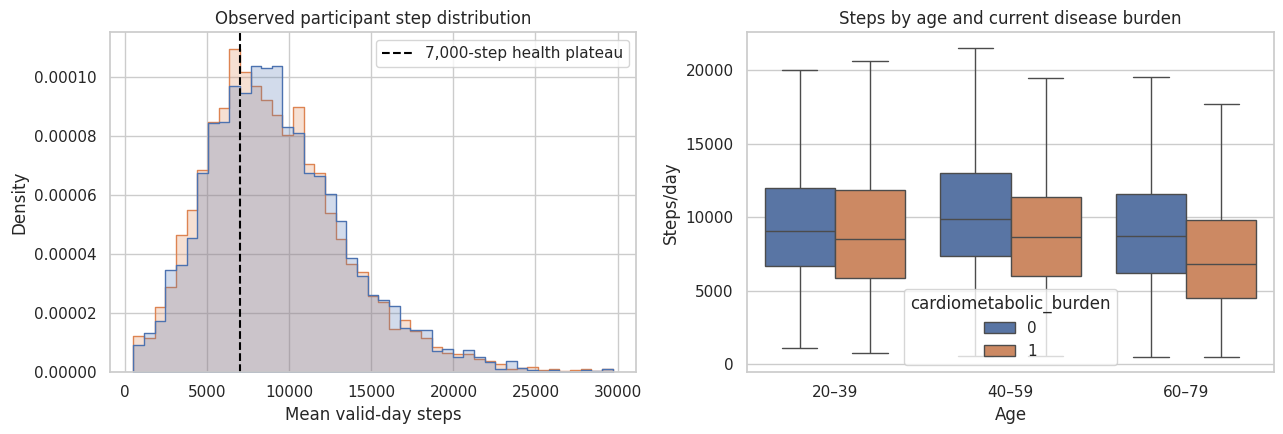

,baseline_steps,step_sd,baseline_sleep_hours,sleep_duration_sd
baseline_steps,1.000,0.679,-0.314,-0.087
step_sd,0.679,1.000,-0.195,0.063
baseline_sleep_hours,-0.314,-0.195,1.000,0.176
sleep_duration_sd,-0.087,0.063,0.176,1.000


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.histplot(data=cohort, x="baseline_steps", hue="cycle", bins=45, element="step", stat="density", common_norm=False, ax=axes[0])
axes[0].axvline(7000, color="black", ls="--", label="7,000-step health plateau")
axes[0].set(xlabel="Mean valid-day steps", title="Observed participant step distribution")
axes[0].legend()
plot_df = cohort.assign(age_group=pd.cut(cohort.RIDAGEYR, [19, 39, 59, 79], labels=["20–39", "40–59", "60–79"]))
sns.boxplot(data=plot_df, x="age_group", y="baseline_steps", hue="cardiometabolic_burden", showfliers=False, ax=axes[1])
axes[1].set(xlabel="Age", ylabel="Steps/day", title="Steps by age and current disease burden")
plt.tight_layout()
plt.show()

wearable_corr = cohort[["baseline_steps", "step_sd", "baseline_sleep_hours", "sleep_duration_sd"]].corr(method="spearman")
display(wearable_corr.round(3))

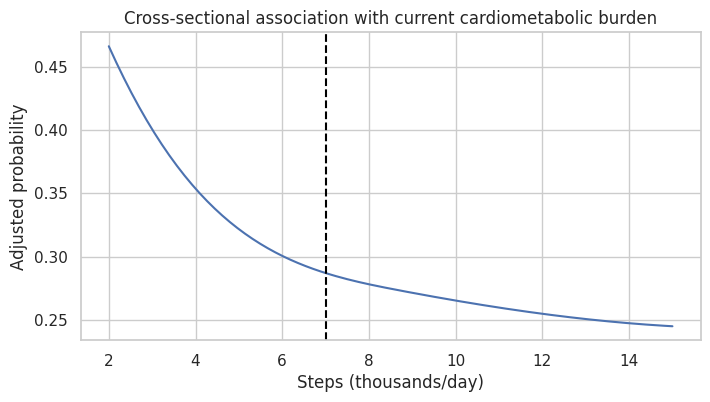

**해석 제한:** 질환 때문에 덜 걷는 역인과와 잔여교란을 분리할 수 없다. 따라서 다음 경제모형은 이 곡선이 아니라 전향 메타분석 HR과 인과 축소계수를 사용한다.

In [5]:
assoc = cohort[[
    "cardiometabolic_burden", "baseline_steps", "RIDAGEYR", "RIAGENDR", "BMXBMI",
    "current_smoker", "survey_weight", "cycle", "SDMVSTRA", "SDMVPSU",
]].dropna().copy()
assoc["steps_k"] = assoc.baseline_steps / 1000
assoc["w_norm"] = assoc.survey_weight / assoc.survey_weight.mean()
assoc["cluster_id"] = assoc.cycle.astype(str) + "_" + assoc.SDMVSTRA.astype(str) + "_" + assoc.SDMVPSU.astype(str)

spline_glm = smf.glm(
    "cardiometabolic_burden ~ bs(steps_k, df=4) + RIDAGEYR + C(RIAGENDR) + BMXBMI + current_smoker",
    data=assoc, family=sm.families.Binomial(), freq_weights=assoc.w_norm,
).fit(cov_type="cluster", cov_kwds={"groups": assoc.cluster_id})

step_grid = np.linspace(2, 15, 150)
pred_frame = pd.DataFrame({
    "steps_k": step_grid, "RIDAGEYR": assoc.RIDAGEYR.median(),
    "RIAGENDR": 2, "BMXBMI": assoc.BMXBMI.median(), "current_smoker": 0,
})
pred_frame["adjusted_probability"] = spline_glm.predict(pred_frame)
ax = pred_frame.plot(x="steps_k", y="adjusted_probability", figsize=(8, 4), legend=False)
ax.axvline(7, color="black", ls="--")
ax.set(xlabel="Steps (thousands/day)", ylabel="Adjusted probability", title="Cross-sectional association with current cardiometabolic burden")
plt.show()
display(Markdown(
    "**해석 제한:** 질환 때문에 덜 걷는 역인과와 잔여교란을 분리할 수 없다. "
    "따라서 다음 경제모형은 이 곡선이 아니라 전향 메타분석 HR과 인과 축소계수를 사용한다."
))

In [6]:
TARGET = "cardiometabolic_burden"
clinical_num = [
    "RIDAGEYR", "BMXBMI", "BMXWAIST", "BPXSY1", "BPXDI1", "LBXGH",
    "LBXSCR", "LBDHDD", "LBXTC", "current_smoker",
]
wearable_num = ["baseline_steps", "step_sd", "baseline_sleep_hours", "sleep_duration_sd"]
categorical = []  # 성별·인종·소득은 정책 타깃 입력에서 제외하고 공정성 평가에만 사용

def risk_pipeline(model_name: str, use_wearable: bool):
    numeric = clinical_num + (wearable_num if use_wearable else [])
    numeric_steps = [SimpleImputer(strategy="median")]
    if model_name == "logit":
        numeric_steps.append(StandardScaler())
    transformers = [("num", make_pipeline(*numeric_steps), numeric)]
    if categorical:
        transformers.append(("cat", make_pipeline(
            SimpleImputer(strategy="most_frequent"),
            OneHotEncoder(handle_unknown="ignore", sparse_output=False),
        ), categorical))
    prep = ColumnTransformer(transformers, sparse_threshold=0)
    model = (
        LogisticRegression(max_iter=2000, C=0.5, random_state=SEED)
        if model_name == "logit" else
        HistGradientBoostingClassifier(
            max_iter=250, max_leaf_nodes=15, learning_rate=0.05,
            l2_regularization=2, random_state=SEED,
        )
    )
    return make_pipeline(prep, model), numeric + categorical

g = cohort[cohort.cycle == "G"].copy().reset_index(drop=True)
h = cohort[cohort.cycle == "H"].copy().reset_index(drop=True)
cv = StratifiedKFold(5, shuffle=True, random_state=SEED)
metric_rows, g_oof = [], {}

for model_name in ["logit", "hgb"]:
    for use_wearable in [False, True]:
        label = f"{model_name}_{'wearable' if use_wearable else 'clinical'}"
        pipe, features = risk_pipeline(model_name, use_wearable)
        oof = cross_val_predict(pipe, g[features], g[TARGET], cv=cv, method="predict_proba", n_jobs=-1)[:, 1]
        pipe.fit(g[features], g[TARGET])
        h_pred = pipe.predict_proba(h[features])[:, 1]
        metric_rows.append({
            "model": label,
            "G OOF AUROC": roc_auc_score(g[TARGET], oof),
            "G OOF Brier": brier_score_loss(g[TARGET], oof),
            "H AUROC": roc_auc_score(h[TARGET], h_pred),
            "H Brier": brier_score_loss(h[TARGET], h_pred),
        })
        g_oof[label] = oof

model_metrics = pd.DataFrame(metric_rows).sort_values(["G OOF Brier", "G OOF AUROC"], ascending=[True, False])
selected_model = model_metrics.iloc[0]["model"]
selected_kind, selected_aug = selected_model.split("_")
selected_pipe, selected_features = risk_pipeline(selected_kind, selected_aug == "wearable")
selected_pipe.fit(g[selected_features], g[TARGET])
g["risk_score"] = g_oof[selected_model]
h["risk_score"] = selected_pipe.predict_proba(h[selected_features])[:, 1]
display(model_metrics.round(4))

clinical_h = model_metrics.loc[model_metrics.model == "logit_clinical", "H AUROC"].iloc[0]
wearable_h = model_metrics.loc[model_metrics.model == "logit_wearable", "H AUROC"].iloc[0]
display(Markdown(
    f"선택 모델은 **{selected_model}**이다. H에서 logistic에 웨어러블을 추가한 AUROC 변화는 "
    f"**{wearable_h - clinical_h:+.4f}**로 매우 작다. 즉 현재 걸음/수면 상태는 임상정보 이후의 위험층화 성능을 "
    "실질적으로 높이지 못하며, 할인 근거는 상태 예측보다 **검증된 증분 개선**이어야 한다."
))

,model,G OOF AUROC,G OOF Brier,H AUROC,H Brier
0,logit_clinical,0.8405,0.1584,0.8323,0.1628
1,logit_wearable,0.8404,0.1585,0.8343,0.1619
3,hgb_wearable,0.8361,0.1610,0.8345,0.1617
2,hgb_clinical,0.8296,0.1644,0.8354,0.1617


선택 모델은 **logit_clinical**이다. H에서 logistic에 웨어러블을 추가한 AUROC 변화는 **+0.0020**로 매우 작다. 즉 현재 걸음/수면 상태는 임상정보 이후의 위험층화 성능을 실질적으로 높이지 못하며, 할인 근거는 상태 예측보다 **검증된 증분 개선**이어야 한다.

In [7]:
PREMIUM_BY_TIER = {1: 39380.0, 2: 97580.0, 3: 124990.0}
LEGACY_EFFECTIVE_LOSS_RATIO = 7904.531543 / 62216.9
risk_cut_65, risk_cut_91 = g.risk_score.quantile([0.65, 0.91])

def attach_portfolio(frame: pd.DataFrame) -> pd.DataFrame:
    out = frame.copy()
    out["risk_tier"] = np.select(
        [out.risk_score <= risk_cut_65, out.risk_score <= risk_cut_91], [1, 2], default=3,
    )
    out["premium"] = out.risk_tier.map(PREMIUM_BY_TIER).astype(float)
    out["w"] = out.survey_weight.clip(lower=0)
    return out

g, h = attach_portfolio(g), attach_portfolio(h)
portfolio_summary = pd.DataFrame({
    "cycle": ["G", "H"],
    "weighted premium": [wmean(g.premium, g.w), wmean(h.premium, h.w)],
    "legacy m": LEGACY_EFFECTIVE_LOSS_RATIO,
    "weighted step-modifiable claim": [
        wmean(g.premium * LEGACY_EFFECTIVE_LOSS_RATIO, g.w),
        wmean(h.premium * LEGACY_EFFECTIVE_LOSS_RATIO, h.w),
    ],
})
display(portfolio_summary.round(2))

,cycle,weighted premium,legacy m,weighted step-modifiable claim
0,G,58281.66,0.13,7404.57
1,H,59891.94,0.13,7609.15


In [8]:
POLICY_DEFAULTS = pd.Series({
    "reference cap": "5%",
    "reference target": "+1,000 steps/day",
    "1-year response at reference": "464 steps/day",
    "CVD HR, 7k vs 2k": "0.75 [0.67, 0.85]",
    "causal shrinkage κ": 0.25,
    "legacy effective modifiable loss ratio m": LEGACY_EFFECTIVE_LOSS_RATIO,
    "program/admin cost": "0 KRW (upper-bound first)",
})
display(POLICY_DEFAULTS.to_frame("base assumption"))

def random_arrays(frame: pd.DataFrame, reps: int = 48):
    local_rng = np.random.default_rng(SEED + (0 if frame.cycle.iloc[0] == "G" else 1))
    u = local_rng.random((len(frame), reps))
    sigma = np.sqrt(np.log(1 + 0.8**2))
    response_multiplier = local_rng.lognormal(-sigma**2 / 2, sigma, size=(len(frame), reps))
    return u, response_multiplier

common_draws = {"G": random_arrays(g), "H": random_arrays(h)}
risk_thresholds = {
    share: (-np.inf if share == 1 else g.risk_score.quantile(1 - share))
    for share in [1, 0.5, 0.25]
}

def evaluate_policy(
    frame: pd.DataFrame,
    cap: float,
    target_gain: int,
    risk_share: float,
    effective_loss_ratio: float = LEGACY_EFFECTIVE_LOSS_RATIO,
    causal_shrinkage: float = 0.25,
    reference_steps: float = 464,
    hr_7000_vs_2000: float = 0.75,
    admin_cost: float = 0,
    return_individual: bool = False,
):
    u, multiplier = common_draws[frame.cycle.iloc[0]]
    threshold = risk_thresholds[risk_share]
    eligible = ((frame.baseline_steps < 7000) & (frame.risk_score >= threshold)).to_numpy()[:, None]

    if cap == 0:
        participation = np.zeros_like(u, dtype=bool)
        response = np.zeros_like(u)
    else:
        p_join = 0.469 + 0.177 * (1 - np.exp(-cap / 0.01))
        participation = eligible & (u < p_join)
        conditional_mean = reference_steps * (cap / 0.05) * (1000 / target_gain)
        response = participation * np.minimum(2500, conditional_mean * multiplier)

    baseline = frame.baseline_steps.to_numpy()[:, None]
    health_gain = np.maximum(0, np.minimum(baseline + response, 7000) - np.minimum(baseline, 7000))
    observed_hr = np.exp(np.log(hr_7000_vs_2000) * health_gain / 5000)
    causal_hr = observed_hr**causal_shrinkage
    premium = frame.premium.to_numpy()[:, None]
    saving = premium * effective_loss_ratio * (1 - causal_hr)
    reward = premium * cap * np.minimum(response / target_gain, 1)
    admin = admin_cost * participation

    individual = pd.DataFrame({
        "saving": saving.mean(axis=1), "reward": reward.mean(axis=1),
        "admin": admin.mean(axis=1), "net": (saving - reward - admin).mean(axis=1),
        "step_gain": response.mean(axis=1), "join": participation.mean(axis=1),
        "earn": (reward > 0).mean(axis=1),
    }, index=frame.index)
    result = {
        "cap": cap, "target_gain": target_gain, "risk_share": risk_share,
        "mean_saving": wmean(individual.saving, frame.w),
        "mean_reward": wmean(individual.reward, frame.w),
        "mean_admin": wmean(individual.admin, frame.w),
        "mean_net": wmean(individual.net, frame.w),
        "mean_step_gain": wmean(individual.step_gain, frame.w),
        "portfolio_join_rate": wmean(individual["join"], frame.w),
        "portfolio_earn_rate": wmean(individual.earn, frame.w),
        "eligible_share": wmean(eligible[:, 0], frame.w),
    }
    join_rate = result["portfolio_join_rate"]
    result["reward_per_joiner"] = result["mean_reward"] / join_rate if join_rate else 0
    result["steps_per_joiner"] = result["mean_step_gain"] / join_rate if join_rate else 0
    return (result, individual) if return_individual else result

# 가장 작은 runnable check: 돈/위험 경계와 monotonicity
zero = evaluate_policy(g, 0, 1000, 1)
low = evaluate_policy(g, 0.005, 1000, 1)
high = evaluate_policy(g, 0.01, 1000, 1)
assert zero["mean_net"] == zero["mean_reward"] == zero["mean_saving"] == 0
assert 0 <= low["mean_reward"] < high["mean_reward"]
assert low["mean_saving"] >= 0 and low["mean_reward"] >= 0
assert all(0 <= x <= 1 for x in [low["portfolio_join_rate"], low["portfolio_earn_rate"]])

,base assumption
reference cap,5%
reference target,"+1,000 steps/day"
1-year response at reference,464 steps/day
"CVD HR, 7k vs 2k","0.75 [0.67, 0.85]"
causal shrinkage κ,0.25
legacy effective modifiable loss ratio m,0.127048
program/admin cost,0 KRW (upper-bound first)


In [9]:
caps = np.r_[0, np.arange(0.0005, 0.0201, 0.0005), [0.025, 0.03, 0.04, 0.05]]
grid_rows = []
for cap in caps:
    if cap == 0:
        grid_rows.append(evaluate_policy(g, 0, 1000, 1))
        continue
    for target_gain in [500, 1000, 1500]:
        for risk_share in [1, 0.5, 0.25]:
            grid_rows.append(evaluate_policy(g, cap, target_gain, risk_share))

policy_grid = pd.DataFrame(grid_rows).sort_values("mean_net", ascending=False).reset_index(drop=True)
micro_optimum = policy_grid.iloc[0]

# 제품으로 체감 가능한 최소 조건은 통계적 사실이 아니라 사전 business constraint다.
practical_candidates = policy_grid[
    (policy_grid.cap > 0)
    & (policy_grid.reward_per_joiner >= 500)
    & (policy_grid.steps_per_joiner >= 400)
].copy()
practical_best = practical_candidates.iloc[0] if len(practical_candidates) else None

display(policy_grid.head(12).round(4))
if practical_best is not None:
    display(pd.DataFrame([micro_optimum, practical_best], index=["수학적 미세 최적", "최소 체감 제약 최선"]).round(4))

,cap,target_gain,risk_share,mean_saving,mean_reward,mean_admin,mean_net,mean_step_gain,portfolio_join_rate,portfolio_earn_rate,eligible_share,reward_per_joiner,steps_per_joiner
0,0.0015,1500,1.0,0.1693,0.0930,0.0,0.0764,1.3650,0.1462,0.1462,0.2954,0.6358,9.3354
1,0.0010,1000,1.0,0.1669,0.0916,0.0,0.0753,1.3442,0.1440,0.1440,0.2954,0.6361,9.3338
2,0.0005,500,1.0,0.1638,0.0899,0.0,0.0739,1.3199,0.1414,0.1414,0.2954,0.6363,9.3371
3,0.0010,1500,1.0,0.1113,0.0407,0.0,0.0706,0.8961,0.1440,0.1440,0.2954,0.2827,6.2225
4,0.0020,1500,1.0,0.2292,0.1679,0.0,0.0613,1.8486,0.1485,0.1485,0.2954,1.1305,12.4468
5,0.0005,1000,1.0,0.0820,0.0225,0.0,0.0595,0.6599,0.1414,0.1414,0.2954,0.1591,4.6686
6,0.0015,1500,0.5,0.1261,0.0690,0.0,0.0570,0.7577,0.0820,0.0820,0.1655,0.8424,9.2436
7,0.0010,1000,0.5,0.1242,0.0680,0.0,0.0562,0.7451,0.0806,0.0806,0.1655,0.8434,9.2401
8,0.0005,500,0.5,0.1219,0.0668,0.0,0.0551,0.7318,0.0792,0.0792,0.1655,0.8437,9.2449
9,0.0010,1500,0.5,0.0828,0.0302,0.0,0.0526,0.4967,0.0806,0.0806,0.1655,0.3749,6.1601


,cap,target_gain,risk_share,mean_saving,mean_reward,mean_admin,mean_net,mean_step_gain,portfolio_join_rate,portfolio_earn_rate,eligible_share,reward_per_joiner,steps_per_joiner
수학적 미세 최적,0.0015,1500.0,1.00,0.1693,0.0930,0.0,0.0764,1.3650,0.1462,0.1462,0.2954,0.6358,9.3354
최소 체감 제약 최선,0.0250,500.0,0.25,5.3506,118.7689,0.0,-113.4184,28.4902,0.0620,0.0620,0.0990,1915.8712,459.5773


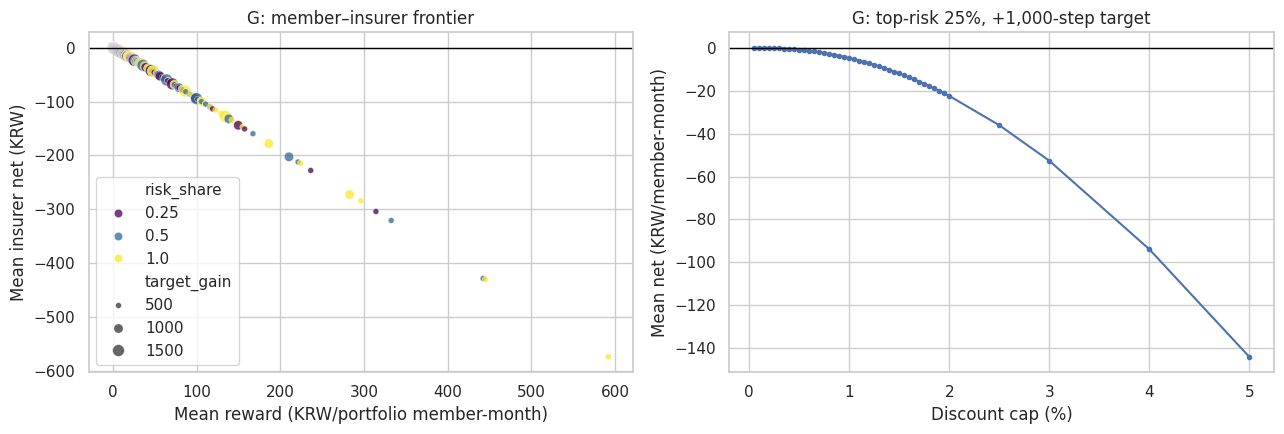

G의 비용 0원 수학적 최적은 상한 **0.15%**, 목표 +1,500보, 위험대상 100%다. 그러나 가입자당 평균 실제 할인은 **0.64원/월**, 걸음 증가는 **9.3보/일**뿐이다. 이는 경제적 제품이 아니라 0% 주변의 수치적 미세점이다. 최소 체감 제약을 만족하는 최선의 G 정책도 순편익이 **-113.4원/인월**이다.

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
plot_grid = policy_grid[policy_grid.cap > 0].copy()
sns.scatterplot(
    data=plot_grid, x="mean_reward", y="mean_net", hue="risk_share", size="target_gain",
    palette="viridis", alpha=0.75, ax=axes[0],
)
axes[0].axhline(0, color="black", lw=1)
axes[0].set(xlabel="Mean reward (KRW/portfolio member-month)", ylabel="Mean insurer net (KRW)", title="G: member–insurer frontier")
slice_grid = policy_grid[(policy_grid.target_gain == 1000) & (policy_grid.risk_share == 0.25)].sort_values("cap")
axes[1].plot(slice_grid.cap * 100, slice_grid.mean_net, marker="o", ms=3)
axes[1].axhline(0, color="black", lw=1)
axes[1].set(xlabel="Discount cap (%)", ylabel="Mean net (KRW/member-month)", title="G: top-risk 25%, +1,000-step target")
plt.tight_layout()
plt.show()

micro_message = (
    f"G의 비용 0원 수학적 최적은 상한 **{micro_optimum.cap*100:.2f}%**, 목표 +{int(micro_optimum.target_gain):,}보, "
    f"위험대상 {micro_optimum.risk_share:.0%}다. 그러나 가입자당 평균 실제 할인은 **{micro_optimum.reward_per_joiner:.2f}원/월**, "
    f"걸음 증가는 **{micro_optimum.steps_per_joiner:.1f}보/일**뿐이다. 이는 경제적 제품이 아니라 0% 주변의 수치적 미세점이다."
)
practical_message = (
    f"최소 체감 제약을 만족하는 최선의 G 정책도 순편익이 **{practical_best.mean_net:,.1f}원/인월**이다."
    if practical_best is not None else "최소 체감 제약을 만족하는 비영 정책이 없다."
)
display(Markdown(micro_message + " " + practical_message))

In [11]:
def evaluate_from_row(frame, row, **kwargs):
    return evaluate_policy(
        frame, float(row.cap), int(row.target_gain), float(row.risk_share), **kwargs,
    )

h_micro, h_micro_individual = evaluate_from_row(h, micro_optimum, return_individual=True)
h_practical = evaluate_from_row(h, practical_best) if practical_best is not None else None

holdout_rows = [h_micro]
holdout_index = ["수학적 미세 최적"]
if h_practical is not None:
    holdout_rows.append(h_practical)
    holdout_index.append("최소 체감 제약 최선")
display(pd.DataFrame(holdout_rows, index=holdout_index).round(4))

cap_check = pd.DataFrame([
    evaluate_policy(h, cap, 1000, 0.25)
    for cap in [0, 0.001, 0.002, 0.005, 0.01, 0.02, 0.05]
])
display(cap_check[[
    "cap", "mean_saving", "mean_reward", "mean_net", "steps_per_joiner", "reward_per_joiner",
]].assign(cap=lambda x: x.cap * 100).rename(columns={"cap": "cap_%"}).round(3))

def psu_bootstrap(frame: pd.DataFrame, values: pd.Series, B: int = 500):
    boot_rng = np.random.default_rng(SEED + 2)
    estimates = []
    strata = list(frame.groupby(["cycle", "SDMVSTRA"], dropna=False))
    for _ in range(B):
        indices = []
        for _, group in strata:
            psus = group.SDMVPSU.dropna().unique()
            if len(psus) == 0:
                indices.extend(group.index)
                continue
            for psu in boot_rng.choice(psus, len(psus), replace=True):
                indices.extend(group.index[group.SDMVPSU == psu])
        indices = np.asarray(indices)
        estimates.append(wmean(values.loc[indices], frame.loc[indices, "w"]))
    return np.asarray(estimates)

h_micro_boot = psu_bootstrap(h, h_micro_individual.net)
sample_uncertainty = pd.Series({
    "H mean net": h_micro["mean_net"],
    "PSU bootstrap 2.5%": np.quantile(h_micro_boot, 0.025),
    "PSU bootstrap 97.5%": np.quantile(h_micro_boot, 0.975),
    "P(net>0), sampling only": np.mean(h_micro_boot > 0),
})
display(sample_uncertainty.to_frame("KRW / portfolio member-month").round(4))

,cap,target_gain,risk_share,mean_saving,mean_reward,mean_admin,mean_net,mean_step_gain,portfolio_join_rate,portfolio_earn_rate,eligible_share,reward_per_joiner,steps_per_joiner
수학적 미세 최적,0.0015,1500,1.00,0.2017,0.1106,0.0,0.0911,1.5575,0.1677,0.1677,0.3363,0.6599,9.2894
최소 체감 제약 최선,0.0250,500,0.25,6.4954,146.4734,0.0,-139.9780,35.5836,0.0770,0.0770,0.1195,1901.5052,461.9434


,cap_%,mean_saving,mean_reward,mean_net,steps_per_joiner,reward_per_joiner
0,0.0,0.000,0.000,0.000,0.000,0.000
1,0.1,0.110,0.060,0.050,9.260,1.014
2,0.2,0.227,0.250,-0.023,18.556,4.064
3,0.5,0.606,1.674,-1.068,46.428,25.414
4,1.0,1.287,7.180,-5.893,92.775,101.556
5,2.0,2.716,30.706,-27.989,185.835,405.068
6,5.0,6.622,185.295,-178.674,462.423,2361.536


,KRW / portfolio member-month
H mean net,0.0911
PSU bootstrap 2.5%,0.0880
PSU bootstrap 97.5%,0.0945
"P(net>0), sampling only",1.0000


best_cap                         best_net                         
kappa        0.00    0.25    0.50    1.00     0.00    0.25    0.50     1.00
m                                                                          
0.050000      0.0  0.0005  0.0005  0.0015      0.0  0.0063  0.0272   0.1229
0.127048      0.0  0.0010  0.0020  0.0040      0.0  0.0486  0.1996   0.8363
0.250000      0.0  0.0020  0.0035  0.0075      0.0  0.1925  0.8094   3.4568
0.500000      0.0  0.0035  0.0075  0.0145      0.0  0.8097  3.4641  14.5443

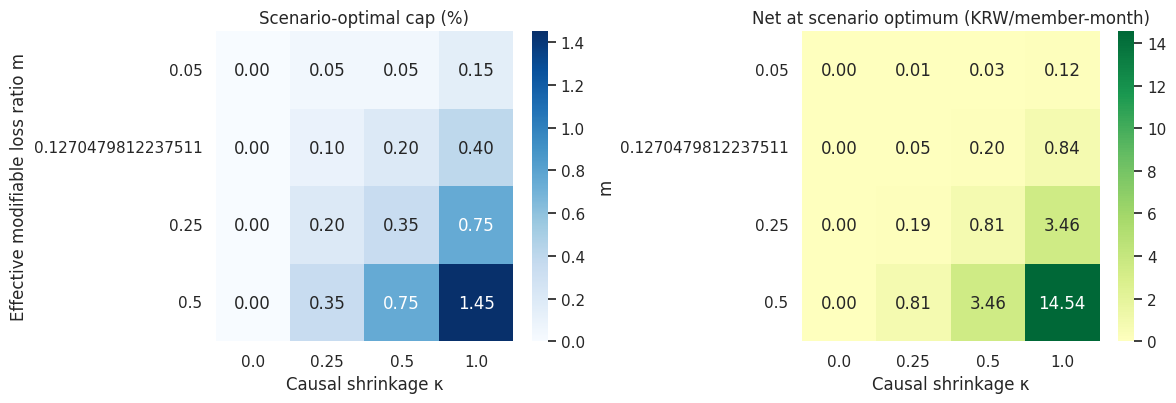

In [12]:
def deterministic_net(
    frame, cap, target_gain, risk_share, m, kappa, reference_steps,
    admin_cost=0, hr_7000_vs_2000=0.75,
):
    threshold = risk_thresholds[risk_share]
    eligible = (frame.baseline_steps < 7000) & (frame.risk_score >= threshold)
    if cap == 0:
        return 0.0
    p_join = 0.469 + 0.177 * (1 - np.exp(-cap / 0.01))
    delta = min(2500, reference_steps * (cap / 0.05) * (1000 / target_gain))
    base = frame.baseline_steps.to_numpy()
    gain = np.maximum(0, np.minimum(base + delta, 7000) - np.minimum(base, 7000))
    causal_hr = np.exp(np.log(hr_7000_vs_2000) * gain / 5000) ** kappa
    net_if_join = (
        frame.premium.to_numpy() * m * (1 - causal_hr)
        - frame.premium.to_numpy() * cap * min(delta / target_gain, 1)
        - admin_cost
    )
    return wmean(eligible * p_join * net_if_join, frame.w)

scenario_rows = []
for m in [0.05, LEGACY_EFFECTIVE_LOSS_RATIO, 0.25, 0.50]:
    for kappa in [0, 0.25, 0.50, 1.0]:
        for reference_steps in [0, 464, 1050]:
            values = [
                (cap, deterministic_net(h, cap, 1000, 0.25, m, kappa, reference_steps))
                for cap in caps
            ]
            cap_star, net_star = max(values, key=lambda item: item[1])
            scenario_rows.append({
                "m": m, "kappa": kappa, "reference_steps": reference_steps,
                "best_cap": cap_star, "best_net": net_star,
            })
structural_envelope = pd.DataFrame(scenario_rows)
base_envelope = structural_envelope[structural_envelope.reference_steps == 464]
display(base_envelope.pivot(index="m", columns="kappa", values=["best_cap", "best_net"]).round(4))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
sns.heatmap(base_envelope.pivot(index="m", columns="kappa", values="best_cap") * 100, annot=True, fmt=".2f", cmap="Blues", ax=axes[0])
axes[0].set(title="Scenario-optimal cap (%)", xlabel="Causal shrinkage κ", ylabel="Effective modifiable loss ratio m")
sns.heatmap(base_envelope.pivot(index="m", columns="kappa", values="best_net"), annot=True, fmt=".2f", cmap="RdYlGn", center=0, ax=axes[1])
axes[1].set(title="Net at scenario optimum (KRW/member-month)", xlabel="Causal shrinkage κ", ylabel="m")
plt.tight_layout()
plt.show()

In [13]:
# 구조 파라미터 Monte Carlo: m은 기존 기준에 고정해 κ·행동효과·HR 불확실성만 분리한다.
def structural_mc(policy, B=2000, admin_cost=0):
    mc_rng = np.random.default_rng(SEED + 3)
    cap, target, share = float(policy.cap), int(policy.target_gain), float(policy.risk_share)
    threshold = risk_thresholds[share]
    eligible = ((h.baseline_steps < 7000) & (h.risk_score >= threshold)).to_numpy()[:, None]
    p_join = 0 if cap == 0 else 0.469 + 0.177 * (1 - np.exp(-cap / 0.01))
    reference = np.clip(mc_rng.normal(464, 83, B), 0, None)
    kappa = mc_rng.uniform(0, 0.5, B)
    log_hr_se = (np.log(0.85) - np.log(0.67)) / (2 * 1.96)
    hr_anchor = np.clip(np.exp(mc_rng.normal(np.log(0.75), log_hr_se, B)), 0.4, 0.99)
    delta = np.minimum(2500, reference * (cap / 0.05) * (1000 / target))
    base = h.baseline_steps.to_numpy()[:, None]
    gain = np.maximum(0, np.minimum(base + delta, 7000) - np.minimum(base, 7000))
    hr = np.exp(np.log(hr_anchor) * gain / 5000) ** kappa
    premium = h.premium.to_numpy()[:, None]
    net = eligible * p_join * (
        premium * LEGACY_EFFECTIVE_LOSS_RATIO * (1 - hr)
        - premium * cap * np.minimum(delta / target, 1)
        - admin_cost
    )
    weights = h.w.to_numpy()[:, None]
    return (net * weights).sum(axis=0) / weights.sum(axis=0)

mc_rows = []
for admin_cost in [0, 1, 100]:
    draws_mc = structural_mc(micro_optimum, admin_cost=admin_cost)
    mc_rows.append({
        "admin per joiner": admin_cost, "mean": draws_mc.mean(),
        "p05": np.quantile(draws_mc, 0.05), "p95": np.quantile(draws_mc, 0.95),
        "P(net>0)": np.mean(draws_mc > 0),
    })
display(pd.DataFrame(mc_rows).round(4))

,admin per joiner,mean,p05,p95,P(net>0)
0,0,0.0916,-0.0880,0.3185,0.709
1,1,-0.0744,-0.2540,0.1525,0.277
2,100,-16.5078,-16.6873,-16.2809,0.000


In [14]:
micro_admin_ceiling = h_micro["mean_net"] / h_micro["portfolio_join_rate"]

break_even = {"micro max admin KRW/joiner-month": micro_admin_ceiling}
if practical_best is not None:
    p = practical_best
    unit_m = evaluate_from_row(h, p, effective_loss_ratio=1, causal_shrinkage=0.25)
    base_practical = evaluate_from_row(h, p)
    required_m = (base_practical["mean_reward"] / unit_m["mean_saving"]) if unit_m["mean_saving"] else np.inf
    break_even["practical required m at κ=.25"] = required_m

    def net_at_kappa(kappa):
        return evaluate_from_row(h, p, causal_shrinkage=kappa)["mean_net"]
    if net_at_kappa(1) >= 0:
        required_kappa = brentq(net_at_kappa, 0, 1)
    else:
        required_kappa = np.inf
    break_even["practical required κ at legacy m"] = required_kappa

display(pd.Series(break_even).to_frame("break-even boundary").round(4))

,break-even boundary
micro max admin KRW/joiner-month,0.5433
practical required m at κ=.25,2.8650
practical required κ at legacy m,inf


In [15]:
fair_policy = practical_best if practical_best is not None else micro_optimum
h_fair_result, h_fair_individual = evaluate_from_row(h, fair_policy, return_individual=True)
h_diag = h.join(h_fair_individual.add_prefix("policy_"))
h_diag["age_group"] = np.where(h_diag.RIDAGEYR >= 60, "60+", "20–59")
h_diag["sex"] = h_diag.RIAGENDR.map({1: "male", 2: "female"})
h_diag["income"] = np.where(h_diag.INDFMPIR < 1.3, "low PIR", "other/missing")
fair_rows = []
for attribute in ["age_group", "sex", "income"]:
    for group_name, part in h_diag.groupby(attribute):
        fair_rows.append({
            "attribute": attribute, "group": group_name, "n": len(part),
            "earn_rate": wmean(part.policy_earn, part.w),
            "reward_KRW": wmean(part.policy_reward, part.w),
            "step_gain": wmean(part.policy_step_gain, part.w),
            "insurer_net_KRW": wmean(part.policy_net, part.w),
        })
fairness_table = pd.DataFrame(fair_rows)
display(fairness_table.round(3))

,attribute,group,n,earn_rate,reward_KRW,step_gain,insurer_net_KRW
0,age_group,20–59,2868,0.029,55.376,13.749,-52.876
1,age_group,60+,1164,0.219,417.945,100.652,-399.543
2,sex,female,2136,0.087,162.251,40.189,-154.980
3,sex,male,1896,0.066,128.943,30.467,-123.309
4,income,low PIR,1271,0.086,162.411,40.217,-154.924
5,income,other/missing,2761,0.074,141.861,34.243,-135.652


In [16]:
sleep_policy = practical_best if practical_best is not None else micro_optimum
sleep_base_result, sleep_base_individual = evaluate_from_row(h, sleep_policy, return_individual=True)
healthy_sleep = h.baseline_sleep_hours.between(7, 9).fillna(False).to_numpy()
extra_sleep_reward = (
    h.premium.to_numpy() * float(sleep_policy.cap) * 0.20
    * healthy_sleep * h_fair_individual["join"].to_numpy()
)
sleep_comparison = pd.Series({
    "healthy-sleep observed share": wmean(healthy_sleep, h.w),
    "added deadweight reward KRW/member-month": wmean(extra_sleep_reward, h.w),
    "step-only net KRW/member-month": sleep_base_result["mean_net"],
    "step + status-sleep bonus net": sleep_base_result["mean_net"] - wmean(extra_sleep_reward, h.w),
})
display(sleep_comparison.to_frame("H holdout").round(3))

,H holdout
healthy-sleep observed share,0.547
added deadweight reward KRW/member-month,20.188
step-only net KRW/member-month,-139.978
step + status-sleep bonus net,-160.166


In [17]:
micro_steps = h_micro["steps_per_joiner"]
micro_reward = h_micro["reward_per_joiner"]
practical_net = h_practical["mean_net"] if h_practical is not None else np.nan
practical_cap = practical_best.cap * 100 if practical_best is not None else np.nan
practical_target = int(practical_best.target_gain) if practical_best is not None else 0
practical_share = practical_best.risk_share if practical_best is not None else np.nan

final_text = f"""
### 결론: 현재 증거에서 배포 가능한 비영 할인 스윗스팟은 없다

1. **수학적 미세점은 존재하지만 제품이 아니다.** G에서 정한 상한 {micro_optimum.cap*100:.2f}%·목표 +{int(micro_optimum.target_gain):,}보 정책은 H에서도 평균 순편익 {h_micro['mean_net']:.3f}원/포트폴리오 인월이었다. 그러나 가입자당 행동증가는 {micro_steps:.1f}보/일, 실제 할인은 {micro_reward:.2f}원/월뿐이며 감당 가능한 운영비는 {micro_admin_ceiling:.2f}원/가입자월이다. 사실상 0%와 같은 해다.

2. **체감 가능한 정책은 손해다.** 사전에 정한 최소 체감 조건(가입자당 ≥500원/월, ≥400보/일)을 만족하는 G 최선은 상한 {practical_cap:.2f}%·+{practical_target:,}보·위험대상 {practical_share:.0%}이며, 손대지 않은 H에서 순편익은 {practical_net:,.1f}원/포트폴리오 인월이었다. 기존 5%·+1,000보·고위험 25% 예시는 H에서 {cap_check.loc[cap_check.cap.eq(.05), 'mean_net'].iloc[0]:,.1f}원/인월이다.

3. **좁은 bootstrap CI는 인과확실성이 아니다.** 고정 가정하 PSU bootstrap은 미세점이 양수라고 보지만, `κ=0`을 포함한 구조 Monte Carlo와 운영비 1원만 넣어도 robust 출시 기준을 통과하지 못한다. 광범위 wellness RCT의 의료비 null과 일치한다.

4. **웨어러블의 올바른 역할은 상태 차별이 아니라 증분 검증이다.** H에서 임상 logistic에 걸음·수면을 추가한 AUROC 변화는 {wearable_h-clinical_h:+.4f}였다. 이미 활동적인 사람에게 상태 할인을 주기보다 baseline <7천보 가입자의 검증된 개선만 월별로 보상해야 deadweight가 줄어든다. 수면 상태 bonus는 건강절감 근거 없이 비용만 늘렸다.

### 권장 다음 단계

- 지금은 전면 할인상품을 출시하지 말고, 저활동·고위험층에서 **0% / 0.5% / 1% 개선보상**을 무작위 pilot로 비교한다.
- baseline 4주 → 12개월 행동 → 이후 paid claims를 분리하고, 처치확률·탈락·기기오차·운영비를 기록한다.
- 실제 `earned premium`, paid claim, 유지율로 `m`을 교체한다. 이 값 없이는 정확한 원화 스윗스팟은 식별되지 않는다.
- 의료적 활동제약에는 동등한 대체목표를 제공하고, 비참여자를 할증하지 않는다.
- pilot 이후에만 cross-fitted DR-learner/causal forest로 이질적 반응과 OPE를 추가한다.

즉, 연구의 완성된 답은 “5–20% 중 하나”가 아니라 **현재 가정에서는 실질적 최적이 0%, 비영 할인이 가능해지는 경계는 위 `m–κ–행동효과–운영비` 표**라는 것이다.
"""
display(Markdown(final_text))


### 결론: 현재 증거에서 배포 가능한 비영 할인 스윗스팟은 없다

1. **수학적 미세점은 존재하지만 제품이 아니다.** G에서 정한 상한 0.15%·목표 +1,500보 정책은 H에서도 평균 순편익 0.091원/포트폴리오 인월이었다. 그러나 가입자당 행동증가는 9.3보/일, 실제 할인은 0.66원/월뿐이며 감당 가능한 운영비는 0.54원/가입자월이다. 사실상 0%와 같은 해다.

2. **체감 가능한 정책은 손해다.** 사전에 정한 최소 체감 조건(가입자당 ≥500원/월, ≥400보/일)을 만족하는 G 최선은 상한 2.50%·+500보·위험대상 25%이며, 손대지 않은 H에서 순편익은 -140.0원/포트폴리오 인월이었다. 기존 5%·+1,000보·고위험 25% 예시는 H에서 -178.7원/인월이다.

3. **좁은 bootstrap CI는 인과확실성이 아니다.** 고정 가정하 PSU bootstrap은 미세점이 양수라고 보지만, `κ=0`을 포함한 구조 Monte Carlo와 운영비 1원만 넣어도 robust 출시 기준을 통과하지 못한다. 광범위 wellness RCT의 의료비 null과 일치한다.

4. **웨어러블의 올바른 역할은 상태 차별이 아니라 증분 검증이다.** H에서 임상 logistic에 걸음·수면을 추가한 AUROC 변화는 +0.0020였다. 이미 활동적인 사람에게 상태 할인을 주기보다 baseline <7천보 가입자의 검증된 개선만 월별로 보상해야 deadweight가 줄어든다. 수면 상태 bonus는 건강절감 근거 없이 비용만 늘렸다.

### 권장 다음 단계

- 지금은 전면 할인상품을 출시하지 말고, 저활동·고위험층에서 **0% / 0.5% / 1% 개선보상**을 무작위 pilot로 비교한다.
- baseline 4주 → 12개월 행동 → 이후 paid claims를 분리하고, 처치확률·탈락·기기오차·운영비를 기록한다.
- 실제 `earned premium`, paid claim, 유지율로 `m`을 교체한다. 이 값 없이는 정확한 원화 스윗스팟은 식별되지 않는다.
- 의료적 활동제약에는 동등한 대체목표를 제공하고, 비참여자를 할증하지 않는다.
- pilot 이후에만 cross-fitted DR-learner/causal forest로 이질적 반응과 OPE를 추가한다.

즉, 연구의 완성된 답은 “5–20% 중 하나”가 아니라 **현재 가정에서는 실질적 최적이 0%, 비영 할인이 가능해지는 경계는 위 `m–κ–행동효과–운영비` 표**라는 것이다.
